# CardioIA — MLP de imagens ECG
**Guilherme Yamada Dantas — RM568506**

Experimento acadêmico Ir Além 2. Fonte: PTB-XL 1.0.3, amostra da Fase1 (120 exames), licença CC BY4.0. Não é validação clínica.

## Protocolo definido antes do teste
NORM=0 (normal), CD/HYP/MI/STTC=1 (anormal). O agrupamento não representa apenas arritmias: são superclasses diagnósticas. Removemos o cabeçalho que expunha o diagnóstico, preservamos originais, convertemos para cinza, redimensionamos para264×136 e achatamos. Pacientes não se cruzam entre partições. Cinco folds estratificados agrupados com seed42: fold0 teste, fold1 validação, restantes treino. Os folds oficiais PTBXL são preservados no manifesto para auditoria, mas não adotados nesta pequena subamostra.

Arquitetura e hiperparâmetros fixos; early stopping usa somente validação. Pesos de classe calculados somente no treino. Teste consultado uma vez por execução, limiar0,5, sem seleção pela métrica de teste.

Instale `extras/ecg/requirements.txt` num venv Python3.12; selecione seu kernel. Execute todas as células do início. O código completo está abaixo e também em `extras/ecg/experiment.py`.


In [1]:
"""Experimento acadêmico reproduzível. Não é dispositivo médico."""
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/cardioia-ecg-mpl')
import csv, json, hashlib
from pathlib import Path
import numpy as np
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow import keras
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
BASE = next(p / 'extras/ecg' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'extras/ecg/experiment.py').exists())
SEED = 42
SIZE = (264, 136)
CROP = (0, 80, 1320, 760)  # grade inicia em y=80; remove título/laudo e margem inferior

def read_csv(path):
    with open(path, newline='', encoding='utf-8') as f: return list(csv.DictReader(f))

def prepare():
    labels = read_csv(BASE/'data/labels_fase1.csv')
    metadata = {r['ecg_id']: r for r in read_csv(BASE/'data/metadata_ptbxl_subset.csv')}
    (BASE/'data/clean').mkdir(exist_ok=True)
    rows, arrays = [], []
    for r in labels:
        p = BASE/'data/originals'/Path(r['arquivo']).name
        im = Image.open(p)
        assert im.size == (1320, 800), (p, im.size)
        clean = im.crop(CROP).convert('L')
        dest = BASE/'data/clean'/f"{int(r['ecg_id']):05d}.png"
        clean.save(dest)
        arrays.append(1.0 - np.asarray(clean.resize(SIZE, Image.Resampling.LANCZOS), dtype=np.float32)/255.0)
        m = metadata[r['ecg_id']]
        rows.append(dict(ecg_id=r['ecg_id'], patient_id=m['patient_id'], strat_fold=m['strat_fold'], superclass=r['superclasse'], label=int(r['superclasse'] != 'NORM'), source_sha256=hashlib.sha256(p.read_bytes()).hexdigest(), clean_sha256=hashlib.sha256(dest.read_bytes()).hexdigest()))
    x = np.asarray(arrays).reshape(len(arrays), -1)
    y = np.array([r['label'] for r in rows])
    groups = np.array([r['patient_id'] for r in rows])
    assert len(set(r['ecg_id'] for r in rows)) == 120
    assert len(set(r['source_sha256'] for r in rows)) == 120
    # Cinco folds estratificados por classe e agrupados por paciente; escolha pré-fixada.
    folds = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(x,y,groups))
    test = folds[0][1]; val = folds[1][1]
    train = np.setdiff1d(np.arange(len(y)), np.r_[test,val])
    parts = {'train': train, 'validation': val, 'test': test}
    for a,b in [('train','validation'),('train','test'),('validation','test')]:
        assert not set(groups[parts[a]]) & set(groups[parts[b]])
    for name, indices in parts.items():
        assert set(y[indices]) == {0,1}
        for i in indices: rows[i]['split'] = name
    with open(BASE/'data/manifest.csv','w',newline='') as f:
        w=csv.DictWriter(f,fieldnames=list(rows[0]));w.writeheader();w.writerows(rows)
    return x,y,parts,rows

def metrics(y,p,prob=None):
    result = {'accuracy':float(accuracy_score(y,p)), 'balanced_accuracy':float(balanced_accuracy_score(y,p)), 'confusion_matrix':confusion_matrix(y,p,labels=[0,1]).tolist(), 'per_class':classification_report(y,p,labels=[0,1],target_names=['normal','anormal'],output_dict=True,zero_division=0)}
    if prob is not None: result['roc_auc'] = float(roc_auc_score(y,prob))
    return result

def run():
    keras.utils.set_random_seed(SEED)
    tf.config.experimental.enable_op_determinism()
    x,y,parts,rows=prepare()
    tr,va,te=[parts[k] for k in ['train','validation','test']]
    # MLP pura: pixels achatados -> Dense -> Dropout -> Dense -> sigmoide.
    model=keras.Sequential([keras.layers.Input((x.shape[1],)), keras.layers.Dense(32,activation='relu',kernel_regularizer=keras.regularizers.l2(.001)), keras.layers.Dropout(.3), keras.layers.Dense(16,activation='relu'),keras.layers.Dense(1,activation='sigmoid')])
    model.compile(optimizer=keras.optimizers.Adam(.001),loss='binary_crossentropy',metrics=['accuracy'])
    weights={c:len(tr)/(2*int(np.sum(y[tr]==c))) for c in [0,1]}
    history=model.fit(x[tr],y[tr],validation_data=(x[va],y[va]),epochs=60,batch_size=16,class_weight=weights,callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)],verbose=0)
    prob=model.predict(x[te],verbose=0).ravel(); pred=(prob>=.5).astype(int)
    baseline=np.full(len(te),int(np.bincount(y[tr]).argmax()))
    report={'seed':SEED,'tensorflow':tf.__version__,'keras':keras.__version__,'input_shape':list(SIZE),'crop':list(CROP),'parameters':model.count_params(),'epochs_run':len(history.history['loss']),'best_epoch':int(np.argmin(history.history['val_loss']))+1,'threshold':.5,'class_weights':weights,'split':{k:{'n':len(v),'normal':int(sum(y[v]==0)),'anormal':int(sum(y[v]==1)),'patients':len(set(rows[i]['patient_id'] for i in v))} for k,v in parts.items()},'test':metrics(y[te],pred,prob),'baseline':metrics(y[te],baseline),'validation':metrics(y[va],(model.predict(x[va],verbose=0).ravel()>=.5).astype(int))}
    out=BASE/'artifacts';out.mkdir(exist_ok=True)
    (out/'metrics.json').write_text(json.dumps(report,indent=2))
    (out/'history.json').write_text(json.dumps(history.history,indent=2))
    model.save(out/'mlp_ecg.keras')
    predictions=[{'ecg_id':rows[i]['ecg_id'],'label':int(y[i]),'prediction':int(pred[j]),'prob_anormal':float(prob[j]),'correct':bool(y[i]==pred[j])} for j,i in enumerate(te)]
    (out/'test_predictions.json').write_text(json.dumps(predictions,indent=2))
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    for k in ['loss','val_loss']: axes[0].plot(history.history[k],label=k)
    axes[0].legend();axes[0].set_title('Treino e validação');axes[0].set_xlabel('Época')
    axes[1].imshow(report['test']['confusion_matrix'],cmap='Blues')
    for i in range(2):
        for j in range(2):axes[1].text(j,i,str(report['test']['confusion_matrix'][i][j]),ha='center')
    axes[1].set(xticks=[0,1],yticks=[0,1],xticklabels=['normal','anormal'],yticklabels=['normal','anormal'],xlabel='Predição',ylabel='Real',title='Teste por paciente')
    fig.tight_layout();fig.savefig(out/'evaluation.png',dpi=150);plt.close(fig)
    print(json.dumps(report,indent=2))
    return report




Matplotlib is building the font cache; this may take a moment.


## Executar preparação, treinamento e avaliação

In [2]:
report = run()

E0000 00:00:1791344190.276382 13767048 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


{
  "seed": 42,
  "tensorflow": "2.21.0",
  "keras": "3.15.1",
  "input_shape": [
    264,
    136
  ],
  "crop": [
    0,
    80,
    1320,
    760
  ],
  "parameters": 1149505,
  "epochs_run": 15,
  "best_epoch": 7,
  "threshold": 0.5,
  "class_weights": {
    "0": 2.5714285714285716,
    "1": 0.6206896551724138
  },
  "split": {
    "train": {
      "n": 72,
      "normal": 14,
      "anormal": 58,
      "patients": 72
    },
    "validation": {
      "n": 24,
      "normal": 5,
      "anormal": 19,
      "patients": 24
    },
    "test": {
      "n": 24,
      "normal": 5,
      "anormal": 19,
      "patients": 23
    }
  },
  "test": {
    "accuracy": 0.7916666666666666,
    "balanced_accuracy": 0.5,
    "confusion_matrix": [
      [
        0,
        5
      ],
      [
        0,
        19
      ]
    ],
    "per_class": {
      "normal": {
        "precision": 0.0,
        "recall": 0.0,
        "f1-score": 0.0,
        "support": 5.0
      },
      "anormal": {
        "preci

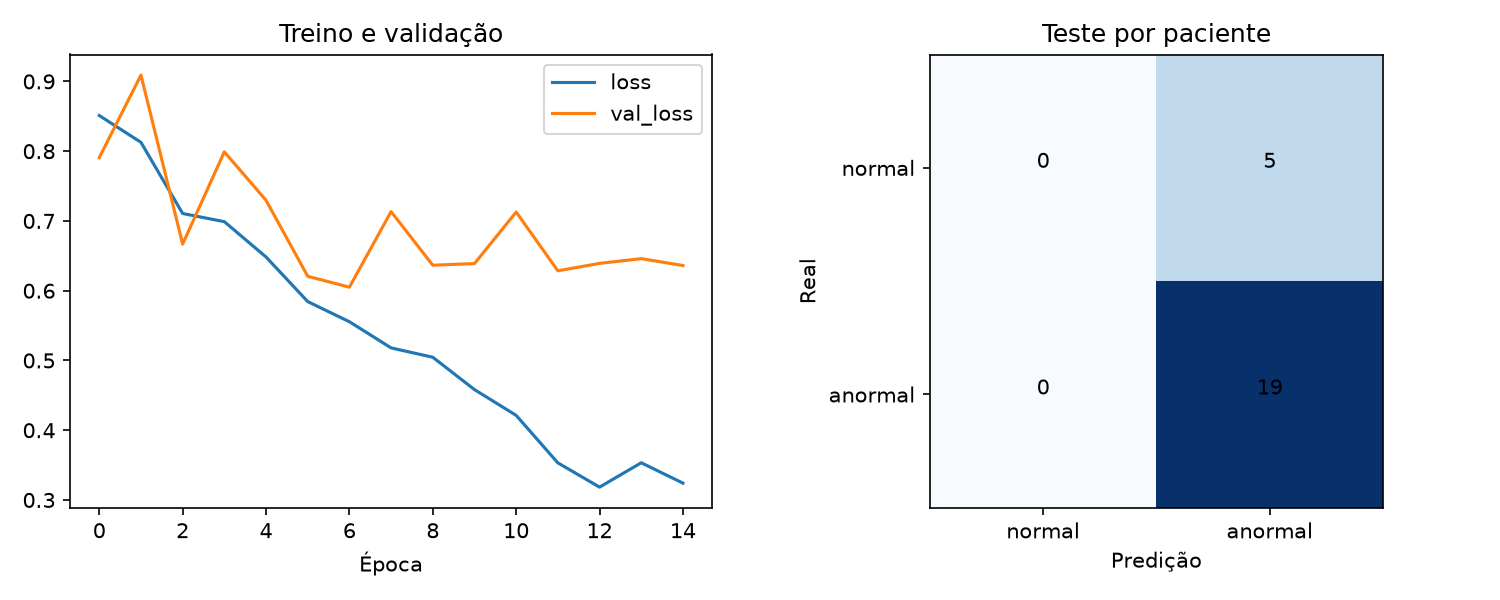

In [3]:
from IPython.display import display, Image as DisplayImage
display(DisplayImage(filename=str(BASE/'artifacts/evaluation.png')))

## Análise crítica

**Resultado executado:** acurácia 79,17%, igual ao baseline; balanced accuracy 50%. Todos os 24 exames previstos como anormais: 5 normais classificados incorretamente, recall normal 0%. A MLP foi executada, mas não obteve uma separação útil neste protocolo.
Compare sempre a MLP com o baseline de classe majoritária. A acurácia isolada esconde falhas em normais. A matriz usa linhas reais e colunas previstas [normal, anormal]. `test_predictions.json` registra inclusive os erros.

120 exames não demonstram generalização clínica; apenas cerca de24 casos em teste geram grande incerteza. A seleção original balanceou cinco superclasses e não representa prevalência hospitalar. Redução da resolução pode apagar características sutis. Idade/sexo/laudo não são entradas, mas remover esses campos não prova equidade. Não há avaliação externa, prospectiva, por equipamento, instituição ou subgrupo; nem autorização para diagnóstico ou triagem reais.

Fontes: [PTB-XL1.0.3](https://physionet.org/content/ptb-xl/1.0.3/), [artigo original](https://doi.org/10.1038/s41597-020-0495-6), [Fase1](https://github.com/japatraderdev99/fiap-preparando-terreno-para-inteligencia-cardiologica).